# Ejemplos de uso del paquete Heurísticos

## Proyecto de Optimización Combinatoria

Esta libreta presenta ejemplos de uso del paquete desarrollado para resolver problemas clásicos de optimización combinatoria.

Problemas incluidos:

1. Problema de la Mochila (Knapsack Problem)
2. Problema del Agente Viajero (Traveling Salesman Problem)

Se utilizan distintos enfoques:

- Métodos heurísticos
- Métodos exactos
- Metaheurísticas

El objetivo es demostrar las capacidades principales del paquete implementado.

## Preparación del entorno

Se clona el repositorio del proyecto y se cargan las librerías necesarias para ejecutar los ejemplos.

También se utilizarán herramientas auxiliares para:

- visualización de resultados
- tablas comparativas
- generación de gráficas

In [1]:
!git clone https://github.com/me400582-arch/heuristicos.git

Cloning into 'heuristicos'...
remote: Enumerating objects: 208, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 208 (delta 31), reused 12 (delta 12), pack-reused 155 (from 2)
Receiving objects: 100% (208/208), 259.93 KiB | 2.43 MiB/s, done.
Resolving deltas: 100% (85/85), done.


In [2]:
import sys

sys.path.append("/content/heuristicos")

print("Repositorio cargado correctamente")

Repositorio cargado correctamente


In [3]:
import random
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)

In [4]:
from heuristicos_pkg.knapsack import(
    mochila_greedy,
    mochila_backtracking,
    mochila_recocido_simulado
)

from heuristicos_pkg.viajero import(
    generar_poblacion,
    calcular_costo,
    dos_opt
)

print("Módulos importados correctamente")

Módulos importados correctamente


# Problema de la Mochila

## Descripción

El problema de la mochila consiste en seleccionar un subconjunto de objetos con pesos y valores asociados.

El objetivo es maximizar el valor transportado sin exceder una capacidad máxima.

Matemáticamente:

\[
\sum_{i=1}^{n}v_i x_i
\]

sujeto a:

\[
\sum_{i=1}^{n}w_i x_i \le C
\]

donde:

- \(v_i\): valor del objeto
- \(w_i\): peso del objeto
- \(x_i\): variable binaria
- \(C\): capacidad máxima

## Definición de instancia de prueba

Se construye una instancia con múltiples objetos y una capacidad límite para comparar distintos algoritmos sobre el mismo problema.

In [5]:
valores=[24,13,23,15,16,28,19,12,18,25,14,17]

pesos=[12,7,11,8,9,14,10,6,9,13,8,7]

capacidad=40

print("Valores")

print(valores)

print()

print("Pesos")

print(pesos)

print()

print("Capacidad")

print(capacidad)

Valores
[24, 13, 23, 15, 16, 28, 19, 12, 18, 25, 14, 17]

Pesos
[12, 7, 11, 8, 9, 14, 10, 6, 9, 13, 8, 7]

Capacidad
40


## Algoritmo Greedy

El método Greedy realiza decisiones localmente óptimas en cada paso.

Su principal ventaja es la rapidez computacional.

In [6]:
seleccion_greedy,valor_greedy=mochila_greedy(
    valores,
    pesos,
    capacidad
)

print("Objetos seleccionados")

print(seleccion_greedy)

print()

print("Valor")

print(valor_greedy)

Objetos seleccionados
[11, 2, 0, 7]

Valor
76


## Algoritmo Backtracking

Backtracking explora sistemáticamente distintas combinaciones posibles para encontrar la solución óptima.

In [7]:
valor_bt,peso_bt,seleccion_bt=mochila_backtracking(
    pesos,
    valores,
    capacidad
)

print("Valor máximo")

print(valor_bt)

print()

print("Peso")

print(peso_bt)

print()

print("Selección")

print(seleccion_bt)

Valor máximo
83

Peso
40

Selección
[1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1]


## Recocido Simulado

El recocido simulado es una metaheurística inspirada en procesos físicos de enfriamiento.

Permite aceptar temporalmente soluciones peores para evitar óptimos locales.

In [8]:
solucion_rs,valor_rs=mochila_recocido_simulado(
    valores,
    pesos,
    capacidad
)

print("Solución")

print(solucion_rs)

print()

print("Valor")

print(valor_rs)

Solución
[0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1]

Valor
83


## Comparación de resultados

Se comparan los resultados obtenidos por los distintos métodos implementados.

In [9]:
resultados=pd.DataFrame({

"Algoritmo":[
"Greedy",
"Backtracking",
"Recocido Simulado"
],

"Valor":[
valor_greedy,
valor_bt,
valor_rs
]

})

resultados

,Algoritmo,Valor
0,Greedy,76
1,Backtracking,83
2,Recocido Simulado,83


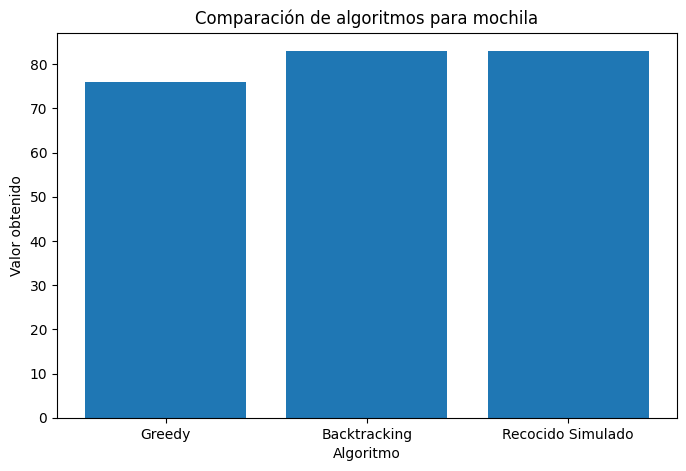

In [10]:
plt.figure(figsize=(8,5))

plt.bar(
    resultados["Algoritmo"],
    resultados["Valor"]
)

plt.title(
    "Comparación de algoritmos para mochila"
)

plt.ylabel(
    "Valor obtenido"
)

plt.xlabel(
    "Algoritmo"
)

plt.show()

# Problema del Agente Viajero (TSP)

## Descripción

El problema del agente viajero consiste en encontrar una ruta de costo mínimo que visite todas las ciudades exactamente una vez.

Debido a la complejidad computacional del problema, frecuentemente se utilizan algoritmos heurísticos.

## Definición de matriz de distancias

La matriz siguiente representa las distancias entre ciudades.

In [11]:
M=[

[0,8,15,20,10,12],
[8,0,9,14,13,11],
[15,9,0,16,18,17],
[20,14,16,0,7,9],
[10,13,18,7,0,6],
[12,11,17,9,6,0]

]

## Generación de población inicial

Se generan distintas rutas candidatas para posteriormente evaluar sus costos.

In [12]:
poblacion=generar_poblacion(
    tamano_poblacion=8,
    n=6
)

for i,ruta in enumerate(poblacion):

    costo=calcular_costo(
        ruta,
        M
    )

    print("Ruta",i+1)

    print(ruta)

    print("Costo:",costo)

    print()

Ruta 1
[4, 5, 2, 1, 0, 3]
Costo: 67

Ruta 2
[1, 4, 2, 3, 0, 5]
Costo: 90

Ruta 3
[0, 4, 5, 3, 2, 1]
Costo: 58

Ruta 4
[0, 5, 4, 1, 3, 2]
Costo: 76

Ruta 5
[5, 2, 3, 1, 0, 4]
Costo: 71

Ruta 6
[1, 2, 3, 5, 4, 0]
Costo: 58

Ruta 7
[4, 0, 1, 2, 5, 3]
Costo: 60

Ruta 8
[2, 0, 4, 5, 3, 1]
Costo: 63



## Aplicación de heurística 2-OPT

La heurística 2-OPT intenta mejorar una solución inicial eliminando cruces innecesarios entre trayectorias.

In [13]:
ruta_original=poblacion[0]

costo_original=calcular_costo(
    ruta_original,
    M
)

mejor_ruta,mejor_costo=dos_opt(
    ruta_original,
    M
)

print("Ruta original")

print(ruta_original)

print()

print("Costo original")

print(costo_original)

print()

print("Ruta optimizada")

print(mejor_ruta)

print()

print("Costo optimizado")

print(mejor_costo)

Ruta original
[4, 5, 2, 1, 0, 3]

Costo original
67

Ruta optimizada
[4, 0, 1, 2, 5, 3]

Costo optimizado
60


In [14]:
comparacion=pd.DataFrame({

"Ruta":[
"Original",
"Optimizada"
],

"Costo":[
costo_original,
mejor_costo
]

})

comparacion

,Ruta,Costo
0,Original,67
1,Optimizada,60


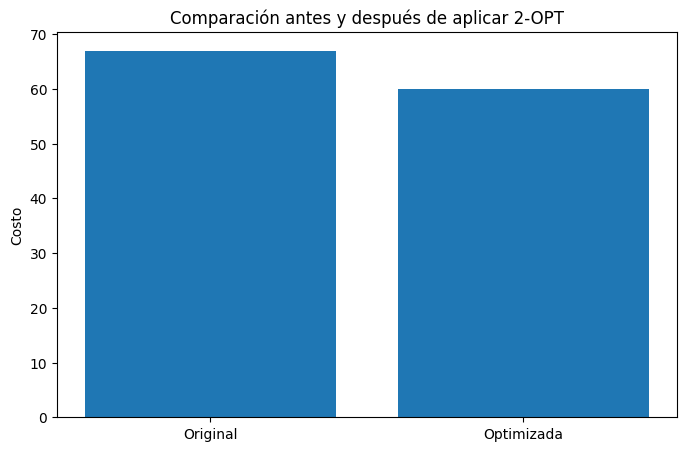

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    comparacion["Ruta"],
    comparacion["Costo"]
)

plt.title(
    "Comparación antes y después de aplicar 2-OPT"
)

plt.ylabel(
    "Costo"
)

plt.show()

# Conclusión

Los ejemplos desarrollados permitieron demostrar el funcionamiento del paquete implementado.

Se observó que:

- Los algoritmos heurísticos ofrecen rapidez computacional.
- Los métodos exactos permiten encontrar soluciones óptimas.
- Las metaheurísticas representan un equilibrio entre tiempo y calidad de solución.

La libreta cumple la función de mostrar aplicaciones prácticas y capacidades principales del paquete desarrollado.